# Phase 1: Synthetic Data Validation

Validate the control-theoretic pairs trading strategy on synthetic OU process data.

**Paper approach**: Model the spread as an Ornstein-Uhlenbeck process and apply a feedback control law `h = -k * (s - μ)` to determine investment allocation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from src.ou_process import generate_ou_path, estimate_ou_params
from src.model import ControlTrader

# OU process parameters (paper-aligned defaults)
KAPPA = 5.0    # mean-reversion speed
MU = 0.0       # long-term mean
SIGMA = 0.5    # volatility
S0 = 0.5       # initial spread (away from mean)
N_STEPS = 2520 # ~10 years of daily data
DT = 1 / 252
SEED = 42

## 1. Generate Synthetic OU Spread

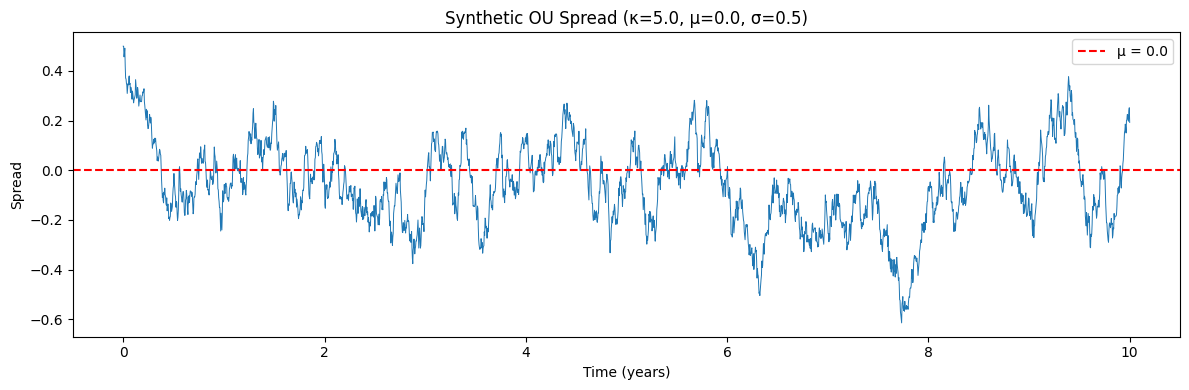

Spread stats: mean=-0.0580, std=0.1684


In [2]:
spread = generate_ou_path(kappa=KAPPA, mu=MU, sigma=SIGMA, s0=S0, dt=DT, n_steps=N_STEPS, seed=SEED)
time = np.arange(len(spread)) / 252

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, spread, linewidth=0.7)
ax.axhline(MU, color='red', linestyle='--', label=f'μ = {MU}')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Spread')
ax.set_title(f'Synthetic OU Spread (κ={KAPPA}, μ={MU}, σ={SIGMA})')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Spread stats: mean={spread.mean():.4f}, std={spread.std():.4f}")

## 2. Verify OU Parameter Estimation

In [3]:
params = estimate_ou_params(spread, dt=DT)
print("Estimated OU Parameters:")
print(f"  κ (kappa): {params['kappa']:.4f}  (true: {KAPPA})")
print(f"  μ (mu):    {params['mu']:.4f}  (true: {MU})")
print(f"  σ (sigma): {params['sigma']:.4f}  (true: {SIGMA})")

Estimated OU Parameters:
  κ (kappa): 4.9412  (true: 5.0)
  μ (mu):    -0.0643  (true: 0.0)
  σ (sigma): 0.5026  (true: 0.5)


## 3. Backtest with ControlTrader

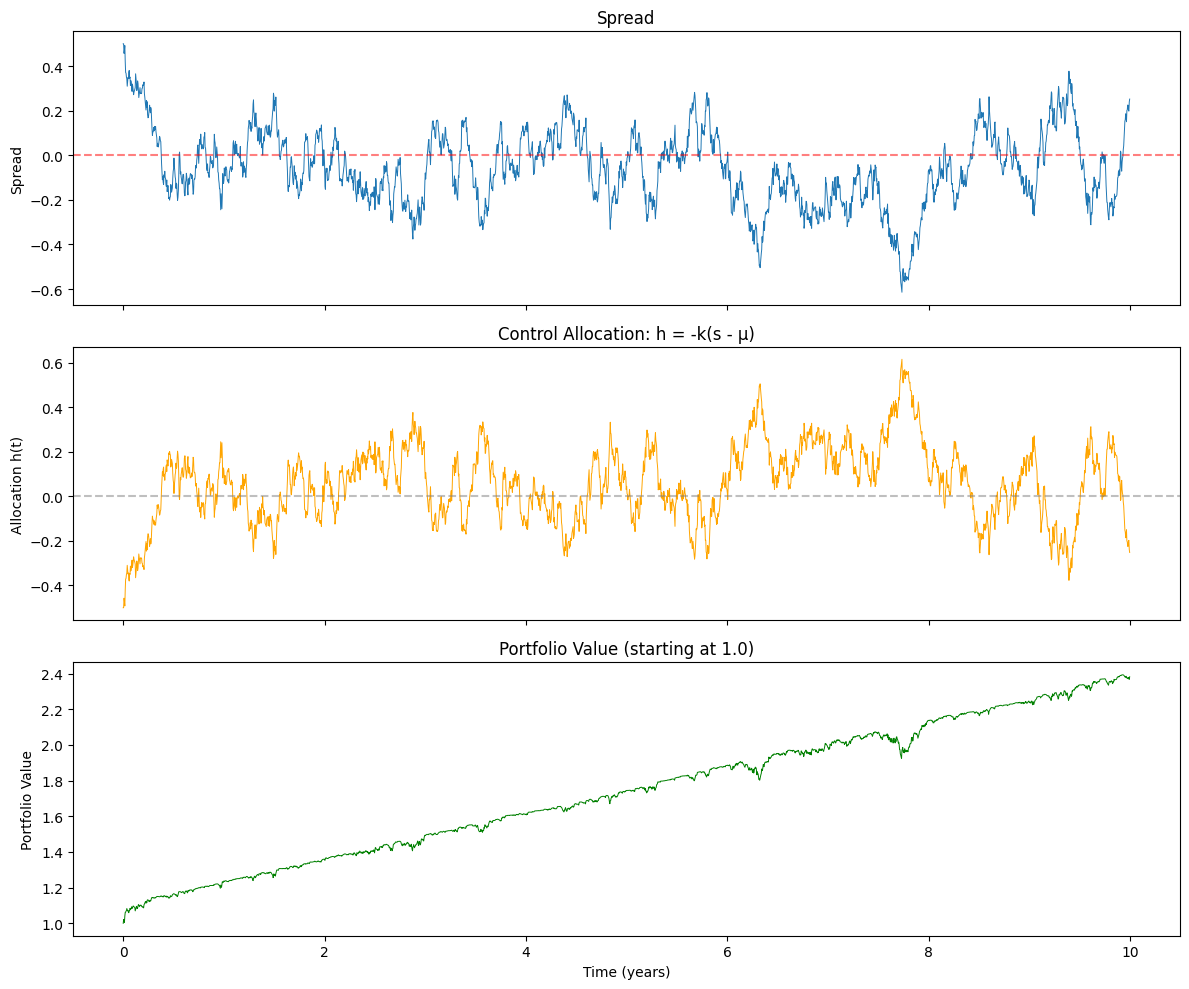

Final portfolio value: 2.3827
Total cumulative PnL:  1.3827
Mean daily PnL:        0.000549
Std daily PnL:         0.005562


In [4]:
# Run backtest with known (true) parameters
trader = ControlTrader(kappa=KAPPA, mu=MU, sigma=SIGMA, k=1.0)
result = trader.run_backtest(spread, dt=DT)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Spread
axes[0].plot(time[:-1], spread[:-1], linewidth=0.7)
axes[0].axhline(MU, color='red', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Spread')
axes[0].set_title('Spread')

# Allocation
axes[1].plot(time[:-1], result['allocations'], linewidth=0.7, color='orange')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Allocation h(t)')
axes[1].set_title('Control Allocation: h = -k(s - μ)')

# Portfolio value
axes[2].plot(time[:-1], result['portfolio_value'], linewidth=0.7, color='green')
axes[2].set_ylabel('Portfolio Value')
axes[2].set_xlabel('Time (years)')
axes[2].set_title('Portfolio Value (starting at 1.0)')

plt.tight_layout()
plt.show()

print(f"Final portfolio value: {result['portfolio_value'][-1]:.4f}")
print(f"Total cumulative PnL:  {result['cumulative_pnl'][-1]:.4f}")
print(f"Mean daily PnL:        {result['returns'].mean():.6f}")
print(f"Std daily PnL:         {result['returns'].std():.6f}")

## 4. Sensitivity to Control Gain k

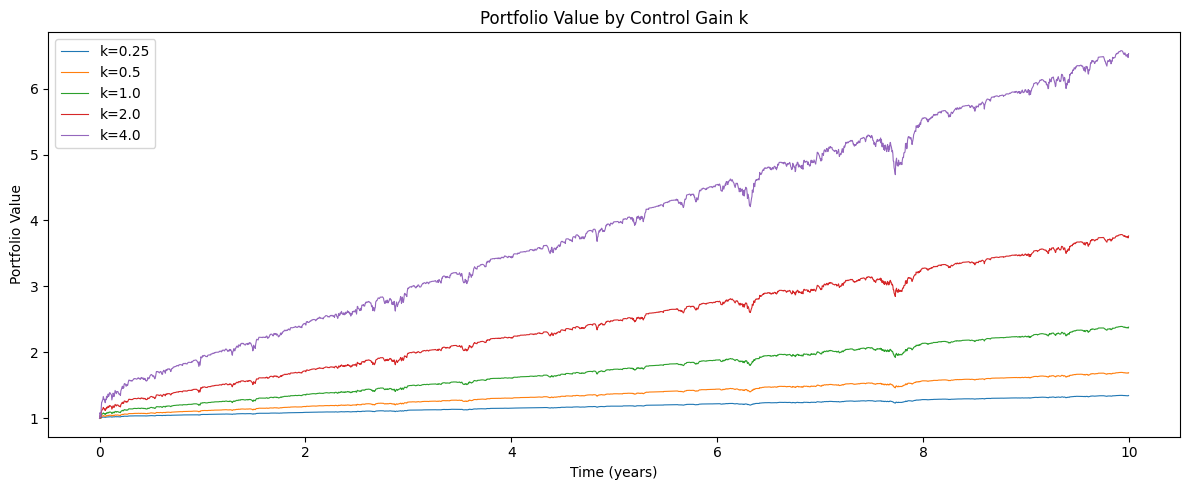

In [5]:
k_values = [0.25, 0.5, 1.0, 2.0, 4.0]
fig, ax = plt.subplots(figsize=(12, 5))

for k in k_values:
    t = ControlTrader(kappa=KAPPA, mu=MU, sigma=SIGMA, k=k)
    r = t.run_backtest(spread, dt=DT)
    ax.plot(time[:-1], r['portfolio_value'], label=f'k={k}', linewidth=0.8)

ax.set_xlabel('Time (years)')
ax.set_ylabel('Portfolio Value')
ax.set_title('Portfolio Value by Control Gain k')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Backtest with Estimated Parameters

Test robustness: use parameters estimated from the data rather than true parameters.

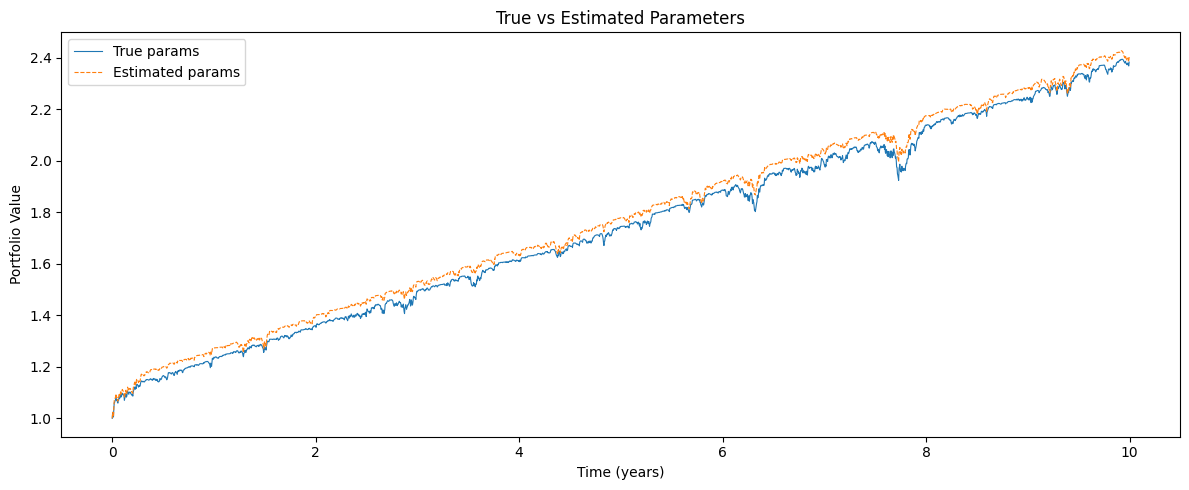

True params - Final PV:      2.3827
Estimated params - Final PV:  2.4024
Estimated κ=4.9412, μ=-0.0643, σ=0.5026


In [6]:
# Use estimated parameters instead of true ones
trader_est = ControlTrader.from_data(spread, k=1.0, dt=DT)
result_est = trader_est.run_backtest(spread, dt=DT)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(time[:-1], result['portfolio_value'], label='True params', linewidth=0.8)
ax.plot(time[:-1], result_est['portfolio_value'], label='Estimated params', linewidth=0.8, linestyle='--')
ax.set_xlabel('Time (years)')
ax.set_ylabel('Portfolio Value')
ax.set_title('True vs Estimated Parameters')
ax.legend()
plt.tight_layout()
plt.show()

print(f"True params - Final PV:      {result['portfolio_value'][-1]:.4f}")
print(f"Estimated params - Final PV:  {result_est['portfolio_value'][-1]:.4f}")
print(f"Estimated κ={trader_est.kappa:.4f}, μ={trader_est.mu:.4f}, σ={trader_est.sigma:.4f}")